# Data Understanding: Cross-Table Relationship Screening

**Purpose:** Systematically explore ALL cross-table relationships across the 17 cleaned tables to determine which joins carry real signal for each of the 4 analytical outcomes. Build evidence-based integrated views for Outcomes 2 and 3; produce screening findings for Outcomes 1 and 4 (teammate's responsibility).

**Phases:**
1. Descriptive overview of cleaned tables
2. Outcome 1 screening (Donor Lapse Prediction) — findings for teammate
3. Outcome 2 screening (Participant Progression)
4. Outcome 3 screening (Social Media to Donations)
5. Outcome 4 screening (Donation-to-Impact Linkage) — findings for teammate
6. Relationship significance summary (all 4 outcomes)
7. Build integrated views for Outcomes 2 and 3

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
import sqlite3
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
CLEAN = Path("cleaned")

table_names = [
    "safehouses", "partners", "partner_assignments", "supporters", "donations",
    "in_kind_donation_items", "donation_allocations", "residents",
    "process_recordings", "home_visitations", "education_records",
    "health_wellbeing_records", "intervention_plans", "incident_reports",
    "social_media_posts", "safehouse_monthly_metrics", "public_impact_snapshots",
]

T = {}
for name in table_names:
    T[name] = pd.read_csv(CLEAN / f"{name}.csv", parse_dates=True)

date_cols_map = {
    "residents": ["date_of_birth","date_of_admission","date_closed","created_at",
                  "date_colb_registered","date_colb_obtained","date_case_study_prepared",
                  "date_enrolled"],
    "donations": ["donation_date"],
    "donation_allocations": ["allocation_date"],
    "process_recordings": ["session_date"],
    "home_visitations": ["visit_date"],
    "education_records": ["record_date"],
    "health_wellbeing_records": ["record_date"],
    "intervention_plans": ["target_date","case_conference_date","created_at","updated_at"],
    "incident_reports": ["incident_date","resolution_date"],
    "social_media_posts": ["created_at"],
    "safehouse_monthly_metrics": ["month_start","month_end"],
    "supporters": ["created_at","first_donation_date"],
    "public_impact_snapshots": ["snapshot_date","published_at"],
}
for tbl, cols in date_cols_map.items():
    for col in cols:
        if col in T[tbl].columns:
            T[tbl][col] = pd.to_datetime(T[tbl][col], errors="coerce")

print("=== Phase 1: Descriptive Overview ===\n")
for name, df in T.items():
    date_cols = [c for c in df.columns if pd.api.types.is_datetime64_any_dtype(df[c])]
    date_range = ""
    if date_cols:
        mn = df[date_cols].min().min()
        mx = df[date_cols].max().max()
        date_range = f"  dates: {mn:%Y-%m-%d} to {mx:%Y-%m-%d}"
    null_pct = (df.isna().sum().sum() / (df.shape[0]*df.shape[1])*100)
    print(f"{name:35s} {df.shape[0]:>5d} rows x {df.shape[1]:>3d} cols  null%: {null_pct:5.1f}%{date_range}")

=== Phase 1: Descriptive Overview ===

safehouses                              9 rows x  13 cols  null%:   7.7%
partners                               30 rows x  12 cols  null%:   7.5%
partner_assignments                    48 rows x   9 cols  null%:  12.3%
supporters                             60 rows x  15 cols  null%:   7.2%  dates: 2022-01-01 to 2026-03-01
donations                             420 rows x  13 cols  null%:  18.1%  dates: 2023-01-09 to 2026-03-01
in_kind_donation_items                129 rows x   9 cols  null%:   0.0%
donation_allocations                  521 rows x   7 cols  null%:  14.3%  dates: 2023-01-09 to 2026-03-01
residents                              60 rows x  55 cols  null%:   8.4%  dates: 2005-11-12 to 2027-02-02
process_recordings                   2819 rows x  19 cols  null%:   5.3%  dates: 2023-01-13 to 2027-02-02
home_visitations                     1337 rows x  16 cols  null%:   5.7%  dates: 2023-02-23 to 2027-01-23
education_records                

## Phase 2: Outcome 1 — Donor Lapse Prediction (screening for teammate)

**Question:** Which active donors show patterns similar to the 15 who went Inactive?

**Target:** `supporters.status` (Active vs Inactive)

Supporter status distribution:
status
Active      45
Inactive    15
Name: count, dtype: int64



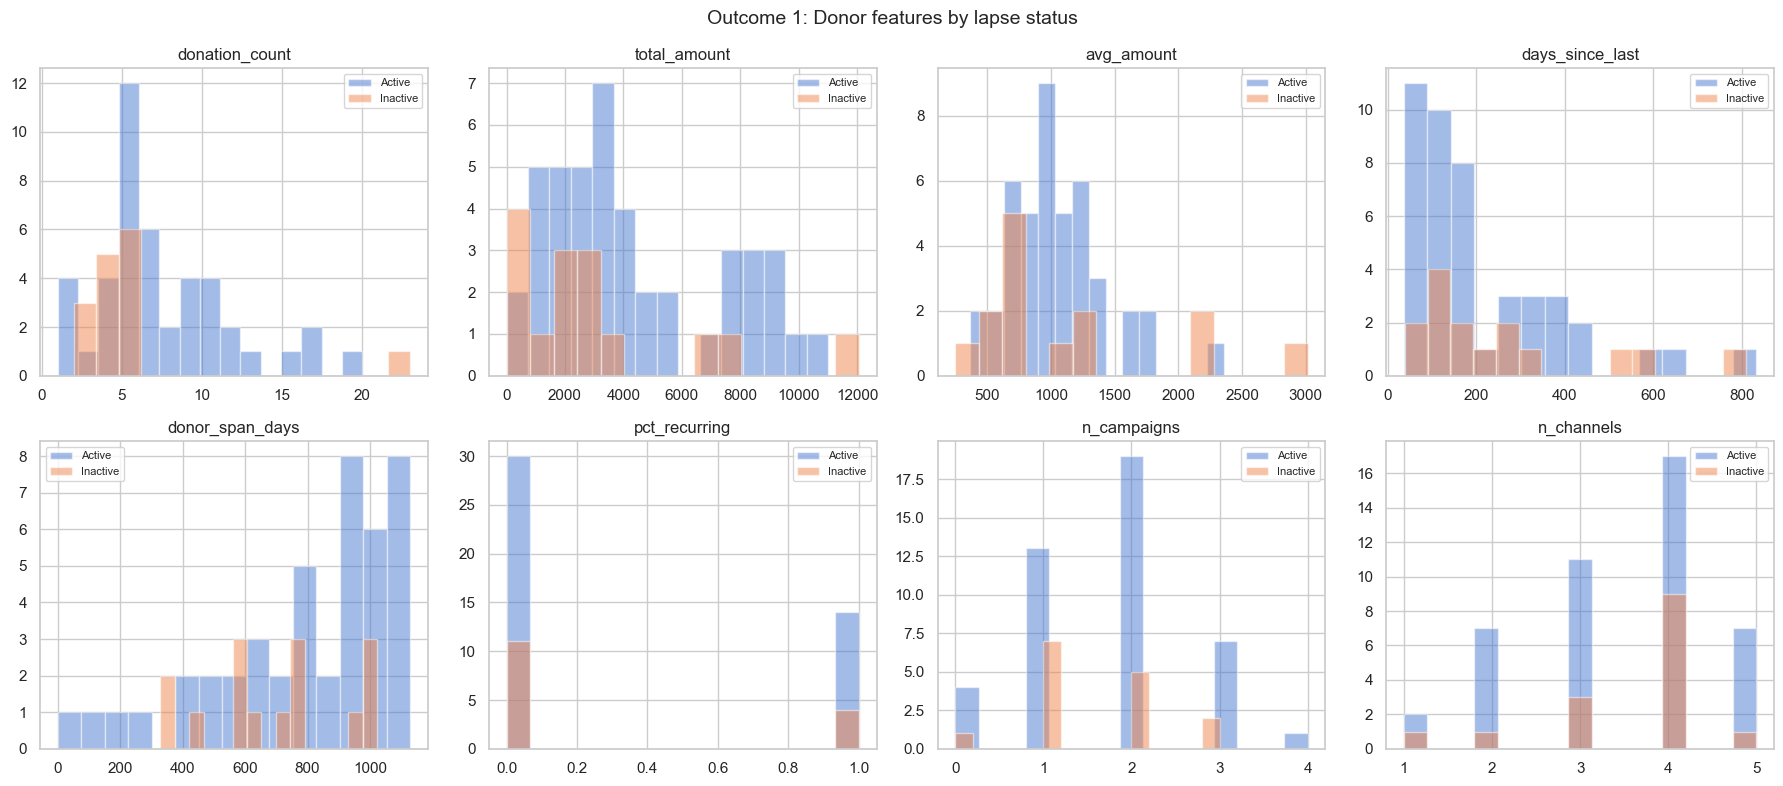

donation_count             U=   466.5  p=0.0172  d=0.454  [include]
total_amount               U=   434.5  p=0.0702  d=0.406  [include]
avg_amount                 U=   347.0  p=0.3989  d=0.226  [exclude]
days_since_last            U=   271.0  p=0.3085  d=0.314  [exclude]
donor_span_days            U=   420.0  p=0.1192  d=0.312  [exclude]
pct_recurring              U=   347.0  p=0.7188  d=0.109  [exclude]
n_campaigns                U=   373.0  p=0.4329  d=0.210  [exclude]
n_channels                 U=   313.0  p=0.7616  d=0.072  [exclude]
supporter_type             chi2=    9.30  p=0.0977  V=0.394  [include]
acquisition_channel        chi2=    1.87  p=0.8664  V=0.177  [exclude]
relationship_type          chi2=    1.21  p=0.5461  V=0.142  [exclude]
region                     chi2=    0.97  p=0.6170  V=0.127  [exclude]
preferred_program_area     chi2=    8.37  p=0.2123  V=0.373  [exclude]
pct_social_channel         U=   437.5  p=0.0579  d=0.498  [include]

--- Outcome 1 screening complete

In [2]:
screening_results = []

def record(outcome, table_pair, join_path, test_type, stat, p_val, effect_size, recommendation):
    screening_results.append({
        "outcome": outcome, "table_pair": table_pair, "join_path": join_path,
        "test": test_type, "statistic": round(stat, 4) if stat else None,
        "p_value": round(p_val, 4) if p_val else None,
        "effect_size": round(effect_size, 4) if effect_size else None,
        "recommendation": recommendation
    })

supporters = T["supporters"].copy()
donations = T["donations"].copy()
allocs = T["donation_allocations"].copy()

lapse_target = (supporters["status"] == "Inactive").astype(int)
print(f"Supporter status distribution:\n{supporters['status'].value_counts()}\n")

# --- Core: Donation aggregates per supporter ---
don_agg = donations.groupby("supporter_id").agg(
    donation_count=("donation_id", "count"),
    total_amount=("amount", "sum"),
    avg_amount=("amount", "mean"),
    first_donation=("donation_date", "min"),
    last_donation=("donation_date", "max"),
    n_recurring=("is_recurring", "sum"),
    n_campaigns=("campaign_name", "nunique"),
    n_channels=("channel_source", "nunique"),
).reset_index()
don_agg["days_since_last"] = (pd.Timestamp("2026-04-06") - pd.to_datetime(don_agg["last_donation"])).dt.days
don_agg["donor_span_days"] = (pd.to_datetime(don_agg["last_donation"]) - pd.to_datetime(don_agg["first_donation"])).dt.days
don_agg["pct_recurring"] = don_agg["n_recurring"] / don_agg["donation_count"]

donor_feat = supporters[["supporter_id","status"]].merge(don_agg, on="supporter_id", how="left")
donor_feat["lapse"] = (donor_feat["status"] == "Inactive").astype(int)

numeric_feats = ["donation_count","total_amount","avg_amount","days_since_last",
                 "donor_span_days","pct_recurring","n_campaigns","n_channels"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, feat in zip(axes.flat, numeric_feats):
    for label, grp in donor_feat.groupby("lapse"):
        vals = grp[feat].dropna()
        ax.hist(vals, alpha=0.5, label=f"{'Inactive' if label else 'Active'}", bins=15)
    ax.set_title(feat)
    ax.legend(fontsize=8)
plt.suptitle("Outcome 1: Donor features by lapse status", fontsize=14)
plt.tight_layout()
plt.show()

for feat in numeric_feats:
    active_vals = donor_feat.loc[donor_feat["lapse"]==0, feat].dropna()
    inactive_vals = donor_feat.loc[donor_feat["lapse"]==1, feat].dropna()
    if len(active_vals) < 3 or len(inactive_vals) < 3:
        continue
    u_stat, p_val = stats.mannwhitneyu(active_vals, inactive_vals, alternative="two-sided")
    effect = abs(active_vals.mean() - inactive_vals.mean()) / (active_vals.std() + 1e-9)
    rec = "include" if p_val < 0.10 else "exclude"
    record("O1-DonorLapse", f"supporters+donations", feat, "Mann-Whitney", u_stat, p_val, effect, rec)
    print(f"{feat:25s}  U={u_stat:8.1f}  p={p_val:.4f}  d={effect:.3f}  [{rec}]")

# --- Core: Categorical features ---
cat_feats = {"supporter_type": supporters, "acquisition_channel": supporters,
             "relationship_type": supporters, "region": supporters}
for feat, src in cat_feats.items():
    ct = pd.crosstab(src[feat], src["status"])
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        continue
    chi2, p_val, dof, _ = stats.chi2_contingency(ct)
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    rec = "include" if p_val < 0.10 else "exclude"
    record("O1-DonorLapse", f"supporters", feat, "Chi2", chi2, p_val, cramers_v, rec)
    print(f"{feat:25s}  chi2={chi2:8.2f}  p={p_val:.4f}  V={cramers_v:.3f}  [{rec}]")

# --- Extended: Allocation program_area preference ---
donor_allocs = donations[["donation_id","supporter_id"]].merge(allocs[["donation_id","program_area"]], on="donation_id")
donor_program = donor_allocs.groupby("supporter_id")["program_area"].agg(lambda x: x.mode().iloc[0] if len(x) > 0 else None).reset_index()
donor_program.columns = ["supporter_id", "preferred_program"]
merged = supporters[["supporter_id","status"]].merge(donor_program, on="supporter_id", how="left")
ct = pd.crosstab(merged["preferred_program"].fillna("None"), merged["status"])
if ct.shape[0] >= 2 and ct.shape[1] >= 2:
    chi2, p_val, dof, _ = stats.chi2_contingency(ct)
    cramers_v = np.sqrt(chi2 / (ct.sum().sum() * (min(ct.shape) - 1)))
    rec = "include" if p_val < 0.10 else "exclude"
    record("O1-DonorLapse", "donations+allocations", "preferred_program_area", "Chi2", chi2, p_val, cramers_v, rec)
    print(f"{'preferred_program_area':25s}  chi2={chi2:8.2f}  p={p_val:.4f}  V={cramers_v:.3f}  [{rec}]")

# --- Extended: Social media referral vs other channels ---
donor_feat_channel = donations.groupby("supporter_id")["channel_source"].agg(
    lambda x: (x == "SocialMedia").mean()
).reset_index()
donor_feat_channel.columns = ["supporter_id", "pct_social_channel"]
merged_ch = supporters[["supporter_id","status"]].merge(donor_feat_channel, on="supporter_id", how="left")
merged_ch["lapse"] = (merged_ch["status"] == "Inactive").astype(int)
active_v = merged_ch.loc[merged_ch["lapse"]==0, "pct_social_channel"].dropna()
inactive_v = merged_ch.loc[merged_ch["lapse"]==1, "pct_social_channel"].dropna()
if len(active_v) >= 3 and len(inactive_v) >= 3:
    u, p = stats.mannwhitneyu(active_v, inactive_v, alternative="two-sided")
    eff = abs(active_v.mean() - inactive_v.mean()) / (active_v.std() + 1e-9)
    rec = "include" if p < 0.10 else "exclude"
    record("O1-DonorLapse", "donations", "pct_social_channel", "Mann-Whitney", u, p, eff, rec)
    print(f"{'pct_social_channel':25s}  U={u:8.1f}  p={p:.4f}  d={eff:.3f}  [{rec}]")

print("\n--- Outcome 1 screening complete ---")

## Phase 3: Outcome 2 — Participant Progression

**Questions:** Which interventions work? Who is at risk of regression?

**Target proxies:** Per-resident education progress slope and health score slope

In [3]:
residents = T["residents"].copy()
edu = T["education_records"].copy()
health = T["health_wellbeing_records"].copy()
sessions = T["process_recordings"].copy()
visits = T["home_visitations"].copy()
incidents = T["incident_reports"].copy()
plans = T["intervention_plans"].copy()
safehouses = T["safehouses"].copy()
partners = T["partners"].copy()
p_assign = T["partner_assignments"].copy()
allocs_o2 = T["donation_allocations"].copy()
sh_metrics = T["safehouse_monthly_metrics"].copy()

# Compute per-resident outcome slopes
def ols_slope(group, y_col):
    g = group.dropna(subset=[y_col])
    if len(g) < 3:
        return np.nan
    x = np.arange(len(g), dtype=float)
    y = g[y_col].values.astype(float)
    slope, _, _, _, _ = stats.linregress(x, y)
    return slope

edu_slopes = edu.sort_values(["resident_id","record_date"]).groupby("resident_id").apply(
    lambda g: ols_slope(g, "progress_percent"), include_groups=False
).reset_index()
edu_slopes.columns = ["resident_id", "edu_progress_slope"]

health_slopes = health.sort_values(["resident_id","record_date"]).groupby("resident_id").apply(
    lambda g: ols_slope(g, "general_health_score"), include_groups=False
).reset_index()
health_slopes.columns = ["resident_id", "health_score_slope"]

outcomes = edu_slopes.merge(health_slopes, on="resident_id", how="outer")
outcomes = outcomes.merge(residents[["resident_id","risk_delta","safehouse_id"]], on="resident_id", how="left")

print(f"Outcome proxy stats:\n{outcomes[['edu_progress_slope','health_score_slope','risk_delta']].describe().round(3)}\n")

# --- Core: Intervention plans services ---
services_exploded = plans.assign(
    services_list=plans["services_provided"].str.split(", ")
).explode("services_list")
svc_per_resident = services_exploded.groupby(["resident_id","services_list"]).size().unstack(fill_value=0)
svc_per_resident = (svc_per_resident > 0).astype(int)
svc_per_resident.columns = [f"has_{c.lower().replace(' ','_')}" for c in svc_per_resident.columns]
svc_merged = outcomes.merge(svc_per_resident, on="resident_id", how="left").fillna(0)

svc_cols = [c for c in svc_merged.columns if c.startswith("has_")]
print("=== Intervention services vs outcome slopes ===")
for svc in svc_cols:
    for target in ["edu_progress_slope", "health_score_slope"]:
        g1 = svc_merged.loc[svc_merged[svc]==1, target].dropna()
        g0 = svc_merged.loc[svc_merged[svc]==0, target].dropna()
        if len(g1) < 3 or len(g0) < 3:
            continue
        u, p = stats.mannwhitneyu(g1, g0, alternative="two-sided")
        d = abs(g1.mean() - g0.mean()) / (g0.std() + 1e-9)
        rec = "include" if p < 0.10 else "exclude"
        record("O2-Progression", "intervention_plans", f"{svc}->{target}", "Mann-Whitney", u, p, d, rec)
        print(f"  {svc:20s} -> {target:25s}  p={p:.4f}  d={d:.3f}  [{rec}]")

# --- Core: Session patterns ---
sess_agg = sessions.groupby("resident_id").agg(
    session_count=("recording_id", "count"),
    avg_duration=("session_duration_minutes", "mean"),
    pct_progress=("progress_noted", "mean"),
    pct_concerns=("concerns_flagged", "mean"),
    pct_emotional_improvement=("emotional_improvement", "mean"),
).reset_index()
sess_merged = outcomes.merge(sess_agg, on="resident_id", how="left")

sess_feats = ["session_count","avg_duration","pct_progress","pct_concerns","pct_emotional_improvement"]
print("\n=== Session patterns vs outcome slopes ===")
for feat in sess_feats:
    for target in ["edu_progress_slope", "health_score_slope"]:
        valid = sess_merged[[feat, target]].dropna()
        if len(valid) < 10:
            continue
        r, p = stats.spearmanr(valid[feat], valid[target])
        rec = "include" if p < 0.10 else "exclude"
        record("O2-Progression", "process_recordings", f"{feat}->{target}", "Spearman", r, p, abs(r), rec)
        print(f"  {feat:30s} -> {target:25s}  r={r:.3f}  p={p:.4f}  [{rec}]")

# --- Core: Home visitation outcomes ---
visit_agg = visits.groupby("resident_id").agg(
    visit_count=("visitation_id", "count"),
    avg_cooperation=("cooperation_numeric", "mean"),
    avg_outcome=("outcome_numeric", "mean"),
    pct_safety_concerns=("safety_concerns_noted", "mean"),
).reset_index()
visit_merged = outcomes.merge(visit_agg, on="resident_id", how="left")

visit_feats = ["visit_count","avg_cooperation","avg_outcome","pct_safety_concerns"]
print("\n=== Home visitation patterns vs outcome slopes ===")
for feat in visit_feats:
    for target in ["edu_progress_slope", "health_score_slope"]:
        valid = visit_merged[[feat, target]].dropna()
        if len(valid) < 10:
            continue
        r, p = stats.spearmanr(valid[feat], valid[target])
        rec = "include" if p < 0.10 else "exclude"
        record("O2-Progression", "home_visitations", f"{feat}->{target}", "Spearman", r, p, abs(r), rec)
        print(f"  {feat:30s} -> {target:25s}  r={r:.3f}  p={p:.4f}  [{rec}]")

# --- Core: Incident frequency ---
inc_agg = incidents.groupby("resident_id").agg(
    incident_count=("incident_id", "count"),
    max_severity=("severity_numeric", "max"),
    avg_severity=("severity_numeric", "mean"),
).reset_index()
inc_merged = outcomes.merge(inc_agg, on="resident_id", how="left").fillna(0)

inc_feats = ["incident_count","max_severity","avg_severity"]
print("\n=== Incident patterns vs outcome slopes ===")
for feat in inc_feats:
    for target in ["edu_progress_slope", "health_score_slope"]:
        valid = inc_merged[[feat, target]].dropna()
        if len(valid) < 10:
            continue
        r, p = stats.spearmanr(valid[feat], valid[target])
        rec = "include" if p < 0.10 else "exclude"
        record("O2-Progression", "incident_reports", f"{feat}->{target}", "Spearman", r, p, abs(r), rec)
        print(f"  {feat:30s} -> {target:25s}  r={r:.3f}  p={p:.4f}  [{rec}]")

# --- Extended: Safehouse characteristics ---
sh_feats = safehouses[["safehouse_id","capacity_girls","capacity_staff","current_occupancy","region"]].copy()
sh_feats["occupancy_ratio"] = sh_feats["current_occupancy"] / sh_feats["capacity_girls"]
sh_merged = outcomes.merge(sh_feats, on="safehouse_id", how="left")

print("\n=== Safehouse characteristics vs outcome slopes (extended) ===")
for feat in ["capacity_girls","capacity_staff","occupancy_ratio"]:
    for target in ["edu_progress_slope", "health_score_slope"]:
        valid = sh_merged[[feat, target]].dropna()
        if len(valid) < 10:
            continue
        r, p = stats.spearmanr(valid[feat], valid[target])
        rec = "include" if p < 0.10 else "exclude"
        record("O2-Progression", "safehouses", f"{feat}->{target}", "Spearman", r, p, abs(r), rec)
        print(f"  {feat:25s} -> {target:25s}  r={r:.3f}  p={p:.4f}  [{rec}]")

for target in ["edu_progress_slope", "health_score_slope"]:
    groups = [g[target].dropna().values for _, g in sh_merged.groupby("region") if len(g[target].dropna()) >= 3]
    if len(groups) >= 2:
        h, p = stats.kruskal(*groups)
        rec = "include" if p < 0.10 else "exclude"
        record("O2-Progression", "safehouses", f"region->{target}", "Kruskal-Wallis", h, p, None, rec)
        print(f"  {'region':25s} -> {target:25s}  H={h:.3f}  p={p:.4f}  [{rec}]")

# --- Extended: Partner coverage ---
partner_coverage = p_assign.groupby("safehouse_id").agg(
    n_partners=("partner_id", "nunique"),
    has_edu_partner=("program_area", lambda x: int("Education" in x.values)),
    has_wellbeing_partner=("program_area", lambda x: int("Wellbeing" in x.values)),
).reset_index()
pc_merged = outcomes.merge(partner_coverage, on="safehouse_id", how="left").fillna(0)

print("\n=== Partner coverage vs outcome slopes (extended) ===")
for feat in ["n_partners","has_edu_partner","has_wellbeing_partner"]:
    for target in ["edu_progress_slope", "health_score_slope"]:
        valid = pc_merged[[feat, target]].dropna()
        if len(valid) < 10:
            continue
        r, p = stats.spearmanr(valid[feat], valid[target])
        rec = "include" if p < 0.10 else "exclude"
        record("O2-Progression", "partner_assignments+partners", f"{feat}->{target}", "Spearman", r, p, abs(r), rec)
        print(f"  {feat:25s} -> {target:25s}  r={r:.3f}  p={p:.4f}  [{rec}]")

# --- Extended: Monthly funding per safehouse ---
allocs_o2["allocation_date"] = pd.to_datetime(allocs_o2["allocation_date"], errors="coerce")
allocs_o2["alloc_month"] = allocs_o2["allocation_date"].dt.to_period("M")
monthly_funding = allocs_o2.groupby(["safehouse_id","alloc_month"])["amount_allocated"].sum().reset_index()
monthly_funding.columns = ["safehouse_id","month","total_funding"]
avg_funding = monthly_funding.groupby("safehouse_id")["total_funding"].mean().reset_index()
avg_funding.columns = ["safehouse_id","avg_monthly_funding"]
fund_merged = outcomes.merge(avg_funding, on="safehouse_id", how="left")

print("\n=== Monthly funding vs outcome slopes (extended) ===")
for target in ["edu_progress_slope", "health_score_slope"]:
    valid = fund_merged[["avg_monthly_funding", target]].dropna()
    if len(valid) >= 10:
        r, p = stats.spearmanr(valid["avg_monthly_funding"], valid[target])
        rec = "include" if p < 0.10 else "exclude"
        record("O2-Progression", "donation_allocations", f"avg_monthly_funding->{target}", "Spearman", r, p, abs(r), rec)
        print(f"  {'avg_monthly_funding':25s} -> {target:25s}  r={r:.3f}  p={p:.4f}  [{rec}]")

print("\n--- Outcome 2 screening complete ---")

Outcome proxy stats:
       edu_progress_slope  health_score_slope  risk_delta
count              60.000              60.000      60.000
mean                6.289               0.037       0.667
std                 3.101               0.030       0.837
min                 0.253              -0.026       0.000
25%                 3.928               0.015       0.000
50%                 5.641               0.040       0.000
75%                 8.387               0.059       1.000
max                13.009               0.115       3.000

=== Intervention services vs outcome slopes ===
  has_caring           -> edu_progress_slope         p=0.6765  d=0.002  [exclude]
  has_caring           -> health_score_slope         p=0.8231  d=0.177  [exclude]
  has_healing          -> edu_progress_slope         p=0.2012  d=0.568  [exclude]
  has_healing          -> health_score_slope         p=0.3269  d=0.392  [exclude]
  has_legal_services   -> edu_progress_slope         p=0.5621  d=0.156  [exclude

## Phase 4: Outcome 3 — Social Media to Donations

**Question:** What content type / platform / timing drives actual donations?

**Target proxy:** `donation_referrals` from social_media_posts

In [4]:
smp = T["social_media_posts"].copy()
don = T["donations"].copy()
snapshots = T["public_impact_snapshots"].copy()

target_col = "donation_referrals"
print(f"Posts with any referral: {(smp[target_col] > 0).sum()} / {len(smp)} ({(smp[target_col] > 0).mean()*100:.1f}%)\n")

# --- Core: Content / timing features ---
cat_features = ["platform","post_type","media_type","day_of_week","content_topic",
                "sentiment_tone","has_call_to_action","call_to_action_type"]
num_features = ["post_hour","num_hashtags","caption_length","mentions_count",
                "is_boosted","features_resident_story"]

print("=== Categorical features vs donation_referrals ===")
for feat in cat_features:
    groups = [g[target_col].dropna().values for _, g in smp.groupby(feat) if len(g) >= 5]
    if len(groups) < 2:
        continue
    h, p = stats.kruskal(*groups)
    eta2 = (h - len(groups) + 1) / (len(smp) - len(groups))
    rec = "include" if p < 0.10 else "exclude"
    record("O3-SocialMedia", "social_media_posts", feat, "Kruskal-Wallis", h, p, abs(eta2), rec)
    print(f"  {feat:25s}  H={h:8.2f}  p={p:.4f}  eta2={eta2:.4f}  [{rec}]")

print("\n=== Numeric features vs donation_referrals ===")
for feat in num_features:
    valid = smp[[feat, target_col]].dropna()
    if len(valid) < 20:
        continue
    r, p = stats.spearmanr(valid[feat], valid[target_col])
    rec = "include" if p < 0.10 else "exclude"
    record("O3-SocialMedia", "social_media_posts", feat, "Spearman", r, p, abs(r), rec)
    print(f"  {feat:25s}  r={r:.4f}  p={p:.4f}  [{rec}]")

# --- Extended: Referred donor profiles ---
referred_donations = don[don["referral_post_id"].notna()].copy()
referred_donations["referral_post_id"] = referred_donations["referral_post_id"].astype(int)
ref_with_supporter = referred_donations.merge(
    T["supporters"][["supporter_id","supporter_type","acquisition_channel","relationship_type"]],
    on="supporter_id", how="left"
)
ref_by_post = ref_with_supporter.groupby("referral_post_id").agg(
    ref_donor_count=("donation_id","count"),
    ref_total_amount=("amount","sum"),
    pct_monetary_donor=("supporter_type", lambda x: (x=="MonetaryDonor").mean()),
    pct_local=("relationship_type", lambda x: (x=="Local").mean()),
).reset_index()
ref_by_post.columns = ["post_id"] + list(ref_by_post.columns[1:])

post_ref = smp[["post_id",target_col,"post_type","platform"]].merge(ref_by_post, on="post_id", how="left")

print("\n=== Extended: Referred donor profiles ===")
for feat in ["pct_monetary_donor","pct_local","ref_total_amount"]:
    valid = post_ref[[feat, target_col]].dropna()
    if len(valid) < 10:
        print(f"  {feat:25s}  Insufficient data (n={len(valid)})")
        continue
    r, p = stats.spearmanr(valid[feat], valid[target_col])
    rec = "include" if p < 0.10 else "exclude"
    record("O3-SocialMedia", "donations+supporters", feat, "Spearman", r, p, abs(r), rec)
    print(f"  {feat:25s}  r={r:.4f}  p={p:.4f}  [{rec}]")

# --- Extended: Campaign alignment ---
campaign_posts = smp[smp["campaign_name"].notna()].groupby("campaign_name")[target_col].sum()
campaign_donations = don[don["campaign_name"].notna()].groupby("campaign_name")["amount"].sum()
campaign_compare = pd.DataFrame({"post_referrals": campaign_posts, "donation_total": campaign_donations}).dropna()
if len(campaign_compare) >= 4:
    r, p = stats.spearmanr(campaign_compare["post_referrals"], campaign_compare["donation_total"])
    rec = "include" if p < 0.10 else "exclude"
    record("O3-SocialMedia", "social_media_posts+donations", "campaign_referrals_vs_totals", "Spearman", r, p, abs(r), rec)
    print(f"\n  Campaign referrals vs totals:  r={r:.4f}  p={p:.4f}  [{rec}]")

# --- Extended: Proximity to impact snapshots ---
snapshots["snapshot_date"] = pd.to_datetime(snapshots["snapshot_date"], errors="coerce")
smp["created_at"] = pd.to_datetime(smp["created_at"], errors="coerce")
snap_dates_sorted = snapshots["snapshot_date"].dropna().sort_values().reset_index(drop=True)

def days_since_snapshot(post_date):
    if pd.isna(post_date):
        return np.nan
    post_ts = pd.Timestamp(post_date)
    diffs = (post_ts - snap_dates_sorted).dt.days
    past = diffs[diffs >= 0]
    return float(past.min()) if len(past) > 0 else np.nan

smp["days_since_snapshot"] = smp["created_at"].apply(days_since_snapshot)
valid = smp[["days_since_snapshot", target_col]].dropna()
if len(valid) >= 20:
    r, p = stats.spearmanr(valid["days_since_snapshot"], valid[target_col])
    rec = "include" if p < 0.10 else "exclude"
    record("O3-SocialMedia", "public_impact_snapshots", "days_since_snapshot", "Spearman", r, p, abs(r), rec)
    print(f"\n  Days since impact snapshot:  r={r:.4f}  p={p:.4f}  [{rec}]")

print("\n--- Outcome 3 screening complete ---")

Posts with any referral: 522 / 812 (64.3%)

=== Categorical features vs donation_referrals ===
  platform                   H=   39.46  p=0.0000  eta2=0.0416  [include]
  post_type                  H=  396.44  p=0.0000  eta2=0.4857  [include]
  media_type                 H=   29.90  p=0.0000  eta2=0.0321  [include]
  day_of_week                H=    3.95  p=0.6839  eta2=-0.0026  [exclude]
  content_topic              H=    9.34  p=0.3145  eta2=0.0017  [exclude]
  sentiment_tone             H=   27.48  p=0.0000  eta2=0.0279  [include]
  has_call_to_action         H=    7.88  p=0.0050  eta2=0.0085  [include]
  call_to_action_type        H=    3.36  p=0.3392  eta2=0.0004  [exclude]

=== Numeric features vs donation_referrals ===
  post_hour                  r=0.2482  p=0.0000  [include]
  num_hashtags               r=0.0310  p=0.3774  [exclude]
  caption_length             r=0.2099  p=0.0000  [include]
  mentions_count             r=0.0208  p=0.5542  [exclude]
  is_boosted                


  Days since impact snapshot:  r=0.0310  p=0.3770  [exclude]

--- Outcome 3 screening complete ---


## Phase 5: Outcome 4 — Donation-to-Impact Linkage (screening for teammate)

**Question:** Which program areas show the strongest donation-to-outcome correlation?

**Target proxies:** `avg_education_progress` and `avg_health_score` from safehouse_monthly_metrics

In [5]:
sh_met = T["safehouse_monthly_metrics"].copy()
allocs_o4 = T["donation_allocations"].copy()
allocs_o4["allocation_date"] = pd.to_datetime(allocs_o4["allocation_date"], errors="coerce")
sh_met["month_start"] = pd.to_datetime(sh_met["month_start"], errors="coerce")

# Build monthly allocation by program area per safehouse
allocs_o4["alloc_month"] = allocs_o4["allocation_date"].dt.to_period("M")
monthly_by_program = allocs_o4.pivot_table(
    index=["safehouse_id","alloc_month"], columns="program_area",
    values="amount_allocated", aggfunc="sum", fill_value=0
).reset_index()
monthly_by_program.columns.name = None
monthly_by_program["alloc_month"] = monthly_by_program["alloc_month"].astype(str)

sh_met["month_key"] = sh_met["month_start"].dt.to_period("M").astype(str)

# Merge allocations with metrics
impact = sh_met.merge(
    monthly_by_program, left_on=["safehouse_id","month_key"],
    right_on=["safehouse_id","alloc_month"], how="left"
).fillna(0)

program_areas = [c for c in monthly_by_program.columns if c not in ["safehouse_id","alloc_month"]]
targets_o4 = ["avg_education_progress", "avg_health_score"]

print("=== Unlagged: allocation by program area vs outcomes ===")
for prog in program_areas:
    for target in targets_o4:
        valid = impact[[prog, target]].dropna()
        valid = valid[valid[target] > 0]
        if len(valid) < 20:
            continue
        r, p = stats.spearmanr(valid[prog], valid[target])
        rec = "include" if p < 0.10 else "exclude"
        record("O4-Impact", f"allocations({prog})", f"{prog}->{target}", "Spearman", r, p, abs(r), rec)
        print(f"  {prog:20s} -> {target:25s}  r={r:.4f}  p={p:.4f}  [{rec}]")

# --- Lagged effects (1-month and 2-month) ---
print("\n=== Lagged effects: 1-month and 2-month ===")
for lag in [1, 2]:
    sh_met_lag = sh_met.copy()
    sh_met_lag["lag_month"] = (sh_met_lag["month_start"] - pd.DateOffset(months=lag)).dt.to_period("M").astype(str)
    impact_lag = sh_met_lag.merge(
        monthly_by_program, left_on=["safehouse_id","lag_month"],
        right_on=["safehouse_id","alloc_month"], how="left"
    ).fillna(0)

    for prog in program_areas:
        for target in targets_o4:
            valid = impact_lag[[prog, target]].dropna()
            valid = valid[valid[target] > 0]
            if len(valid) < 20:
                continue
            r, p = stats.spearmanr(valid[prog], valid[target])
            rec = "include" if p < 0.10 else "exclude"
            record("O4-Impact", f"allocations({prog},lag={lag})", f"{prog}(lag{lag})->{target}", "Spearman", r, p, abs(r), rec)
            print(f"  lag={lag}  {prog:20s} -> {target:25s}  r={r:.4f}  p={p:.4f}  [{rec}]")

# --- Funding per resident ---
sh_active = sh_met[["safehouse_id","month_key","active_residents"]].copy()
fund_per_res = impact.copy()
for prog in program_areas:
    if prog in fund_per_res.columns:
        fund_per_res[f"{prog}_per_resident"] = fund_per_res[prog] / fund_per_res["active_residents"].replace(0, np.nan)

print("\n=== Funding per resident vs outcomes ===")
for prog in program_areas:
    col = f"{prog}_per_resident"
    if col not in fund_per_res.columns:
        continue
    for target in targets_o4:
        valid = fund_per_res[[col, target]].dropna()
        valid = valid[valid[target] > 0]
        if len(valid) < 20:
            continue
        r, p = stats.spearmanr(valid[col], valid[target])
        rec = "include" if p < 0.10 else "exclude"
        record("O4-Impact", f"allocations({prog})/resident", f"{col}->{target}", "Spearman", r, p, abs(r), rec)
        print(f"  {col:35s} -> {target:25s}  r={r:.4f}  p={p:.4f}  [{rec}]")

# --- Simpson's paradox check ---
print("\n=== Simpson's paradox: aggregate vs individual trajectories ===")
individual_slopes = edu_slopes.merge(residents[["resident_id","safehouse_id"]], on="resident_id")
sh_agg_slope = sh_met.sort_values(["safehouse_id","month_start"]).groupby("safehouse_id").apply(
    lambda g: ols_slope(g, "avg_education_progress") if len(g.dropna(subset=["avg_education_progress"])) >= 3 else np.nan,
    include_groups=False
).reset_index()
sh_agg_slope.columns = ["safehouse_id","agg_edu_slope"]
ind_mean = individual_slopes.groupby("safehouse_id")["edu_progress_slope"].mean().reset_index()
ind_mean.columns = ["safehouse_id","mean_individual_slope"]
simpson = sh_agg_slope.merge(ind_mean, on="safehouse_id")
print(simpson.to_string(index=False))
if len(simpson.dropna()) >= 3:
    r, p = stats.spearmanr(simpson["agg_edu_slope"].dropna(), simpson["mean_individual_slope"].dropna())
    sign_agreement = ((simpson["agg_edu_slope"] > 0) == (simpson["mean_individual_slope"] > 0)).mean()
    print(f"\nCorrelation agg vs individual slopes: r={r:.3f} p={p:.4f}")
    print(f"Sign agreement: {sign_agreement*100:.0f}%")
    if sign_agreement < 0.7:
        print("WARNING: Possible Simpson's paradox — aggregate and individual trends diverge for some safehouses")

print("\n--- Outcome 4 screening complete ---")

=== Unlagged: allocation by program area vs outcomes ===
  Education            -> avg_education_progress     r=-0.0118  p=0.8514  [exclude]
  Education            -> avg_health_score           r=0.0831  p=0.1877  [exclude]
  Maintenance          -> avg_education_progress     r=-0.0331  p=0.6001  [exclude]
  Maintenance          -> avg_health_score           r=0.1157  p=0.0661  [include]
  Operations           -> avg_education_progress     r=-0.1085  p=0.0849  [include]
  Operations           -> avg_health_score           r=-0.0014  p=0.9818  [exclude]
  Outreach             -> avg_education_progress     r=-0.0207  p=0.7437  [exclude]
  Outreach             -> avg_health_score           r=-0.0192  p=0.7608  [exclude]
  Transport            -> avg_education_progress     r=-0.0519  p=0.4111  [exclude]
  Transport            -> avg_health_score           r=0.0428  p=0.4980  [exclude]
  Wellbeing            -> avg_education_progress     r=0.0470  p=0.4570  [exclude]
  Wellbeing            

  Outreach_per_resident               -> avg_health_score           r=-0.0275  p=0.6633  [exclude]
  Transport_per_resident              -> avg_education_progress     r=-0.0503  p=0.4261  [exclude]
  Transport_per_resident              -> avg_health_score           r=0.0388  p=0.5394  [exclude]
  Wellbeing_per_resident              -> avg_education_progress     r=0.0433  p=0.4929  [exclude]
  Wellbeing_per_resident              -> avg_health_score           r=0.0132  p=0.8346  [exclude]

=== Simpson's paradox: aggregate vs individual trajectories ===
 safehouse_id  agg_edu_slope  mean_individual_slope
            1       0.998468               6.211772
            2       1.367108               6.931937
            3       0.238801               4.828349
            4       0.728773               6.053921
            5       0.694662               6.554481
            6       0.568156               6.097501
            7      -1.319951               6.767880
            8       0.32039

## Phase 6: Relationship Significance Summary (All 4 Outcomes)

Total relationships tested: 129
Significant (p < 0.10):     26
Not significant:            103


  O1-DonorLapse: 4 significant, 10 excluded

  INCLUDE:
    donation_count                                 p=0.0172  effect=0.4541
    pct_social_channel                             p=0.0579  effect=0.4982
    total_amount                                   p=0.0702  effect=0.4055
    supporter_type                                 p=0.0977  effect=0.3937

  EXCLUDE (10 relationships with p >= 0.10)

  O2-Progression: 6 significant, 42 excluded

  INCLUDE:
    has_teaching->health_score_slope               p=0.0049  effect=2.9764
    max_severity->edu_progress_slope               p=0.0109  effect=0.3265
    incident_count->edu_progress_slope             p=0.0162  effect=0.3092
    avg_monthly_funding->health_score_slope        p=0.0342  effect=0.2739
    avg_severity->edu_progress_slope               p=0.0584  effect=0.2458
    pct_progress->health_score_slope               p=0.0962  effect=0

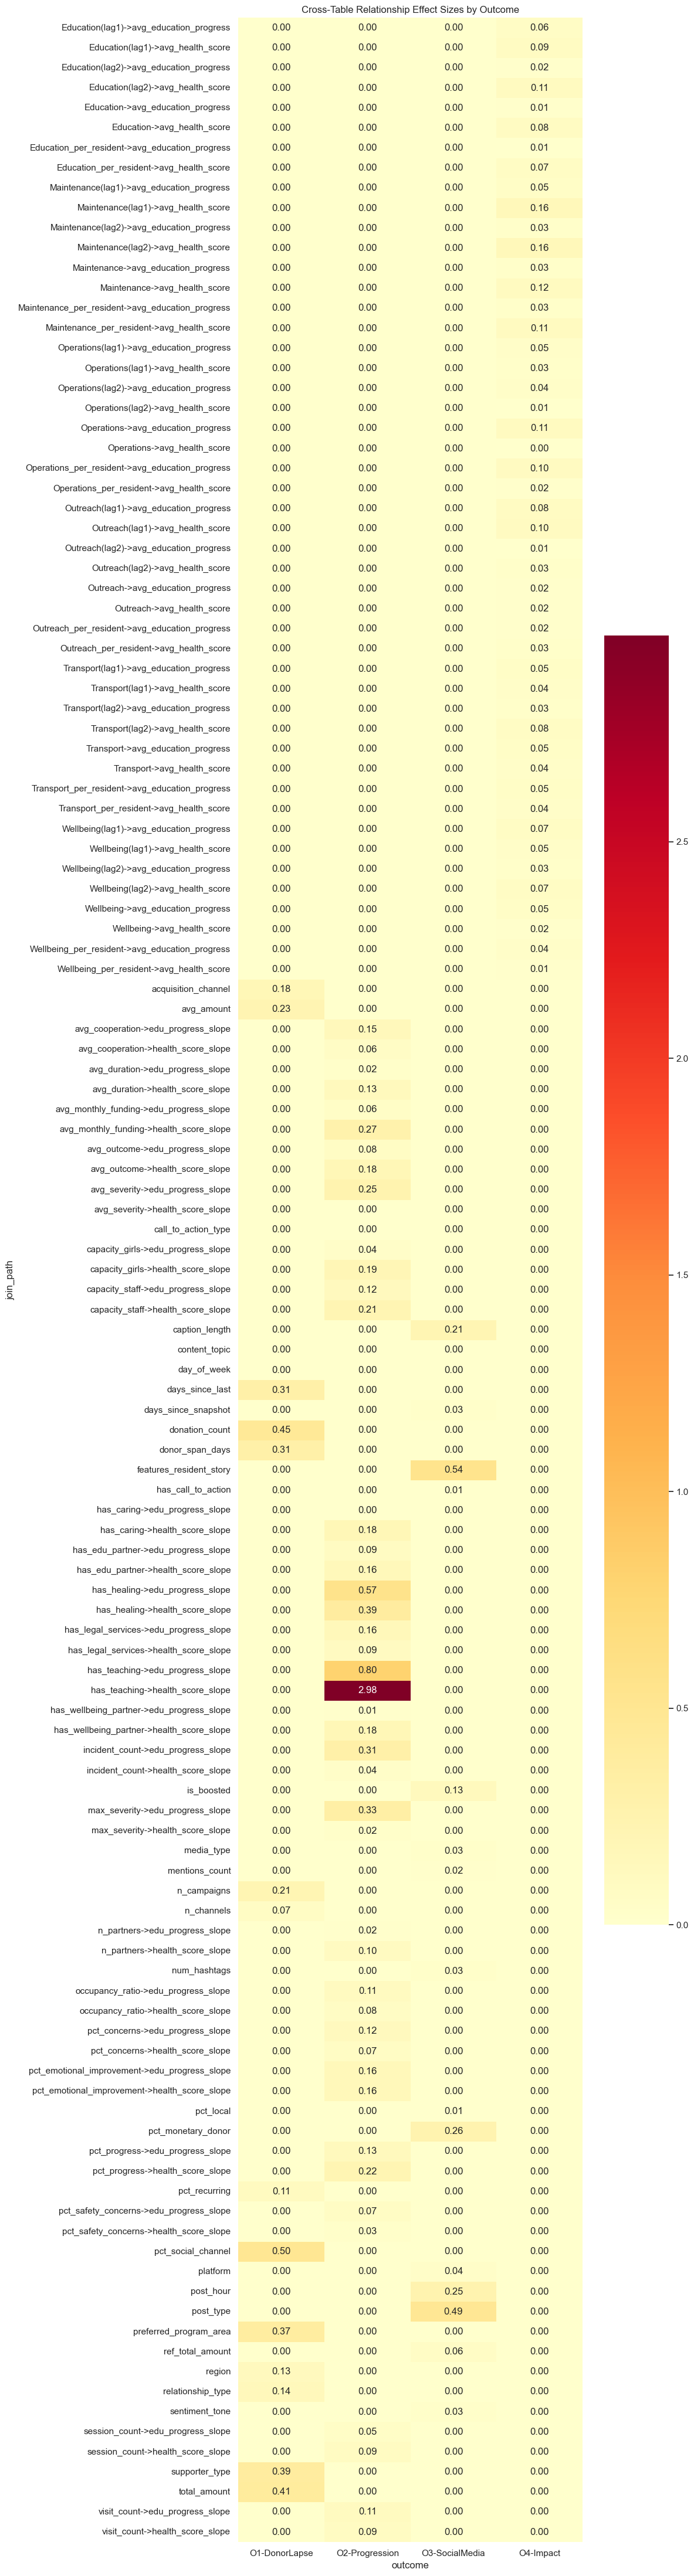


Screening results saved to cleaned/screening_results.csv


In [6]:
results_df = pd.DataFrame(screening_results)
results_df = results_df.sort_values(["outcome","p_value"])

print(f"Total relationships tested: {len(results_df)}")
print(f"Significant (p < 0.10):     {(results_df['recommendation']=='include').sum()}")
print(f"Not significant:            {(results_df['recommendation']=='exclude').sum()}\n")

for outcome in results_df["outcome"].unique():
    subset = results_df[results_df["outcome"] == outcome]
    inc = subset[subset["recommendation"] == "include"]
    exc = subset[subset["recommendation"] == "exclude"]
    print(f"\n{'='*60}")
    print(f"  {outcome}: {len(inc)} significant, {len(exc)} excluded")
    print(f"{'='*60}")
    if len(inc) > 0:
        print("\n  INCLUDE:")
        for _, row in inc.iterrows():
            print(f"    {row['join_path']:45s}  p={row['p_value']:.4f}  effect={row['effect_size']}")
    if len(exc) > 0:
        print(f"\n  EXCLUDE ({len(exc)} relationships with p >= 0.10)")

# Heatmap of effect sizes by outcome
pivot = results_df.pivot_table(index="join_path", columns="outcome", values="effect_size", aggfunc="max")
if pivot.shape[0] > 3:
    fig, ax = plt.subplots(figsize=(12, max(6, len(pivot)*0.35)))
    sns.heatmap(pivot.fillna(0), annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
    ax.set_title("Cross-Table Relationship Effect Sizes by Outcome")
    plt.tight_layout()
    plt.show()

results_df.to_csv(CLEAN / "screening_results.csv", index=False)
print(f"\nScreening results saved to {CLEAN / 'screening_results.csv'}")

## Phase 7: Build Integrated Analytical Views for Outcomes 2 and 3

Views are constructed using the base structure plus any extended relationships that Phase 6 flagged as significant.

In [7]:
sig_o2 = set(results_df[(results_df["outcome"]=="O2-Progression") & (results_df["recommendation"]=="include")]["table_pair"])
sig_o3 = set(results_df[(results_df["outcome"]=="O3-SocialMedia") & (results_df["recommendation"]=="include")]["table_pair"])

print("Significant table pairs for O2:", sig_o2)
print("Significant table pairs for O3:", sig_o3)

# =====================================================================
# RESIDENT TIMELINE — one row per resident per month
# =====================================================================
print("\n=== Building resident_timeline ===")

edu_clean = T["education_records"].copy()
health_clean = T["health_wellbeing_records"].copy()
edu_clean["record_date"] = pd.to_datetime(edu_clean["record_date"])
health_clean["record_date"] = pd.to_datetime(health_clean["record_date"])

timeline = edu_clean.merge(health_clean, on=["resident_id","record_date"], how="inner", suffixes=("_edu","_health"))
print(f"  Base (edu x health inner join): {timeline.shape}")

# Monthly session aggregates
sess_clean = T["process_recordings"].copy()
sess_clean["session_date"] = pd.to_datetime(sess_clean["session_date"])
sess_clean["record_month"] = sess_clean["session_date"].dt.to_period("M")

sess_monthly = sess_clean.groupby(["resident_id","record_month"]).agg(
    session_count=("recording_id","count"),
    avg_duration_min=("session_duration_minutes","mean"),
    pct_progress_noted=("progress_noted","mean"),
    pct_concerns_flagged=("concerns_flagged","mean"),
    pct_emotional_improvement=("emotional_improvement","mean"),
).reset_index()
sess_monthly["record_month"] = sess_monthly["record_month"].astype(str)

timeline["record_month"] = timeline["record_date"].dt.to_period("M").astype(str)
timeline = timeline.merge(sess_monthly, on=["resident_id","record_month"], how="left")
print(f"  + sessions: {timeline.shape}")

# Monthly visit aggregates
vis_clean = T["home_visitations"].copy()
vis_clean["visit_date"] = pd.to_datetime(vis_clean["visit_date"])
vis_clean["record_month"] = vis_clean["visit_date"].dt.to_period("M")

vis_monthly = vis_clean.groupby(["resident_id","record_month"]).agg(
    visit_count=("visitation_id","count"),
    pct_favorable=("outcome_numeric", lambda x: (x == 3).mean()),
    pct_safety_concerns=("safety_concerns_noted","mean"),
    avg_cooperation_score=("cooperation_numeric","mean"),
).reset_index()
vis_monthly["record_month"] = vis_monthly["record_month"].astype(str)

timeline = timeline.merge(vis_monthly, on=["resident_id","record_month"], how="left")
print(f"  + visits: {timeline.shape}")

# Monthly incident aggregates
inc_clean = T["incident_reports"].copy()
inc_clean["incident_date"] = pd.to_datetime(inc_clean["incident_date"])
inc_clean["record_month"] = inc_clean["incident_date"].dt.to_period("M")

inc_monthly = inc_clean.groupby(["resident_id","record_month"]).agg(
    incident_count=("incident_id","count"),
    max_severity_numeric=("severity_numeric","max"),
).reset_index()
inc_monthly["record_month"] = inc_monthly["record_month"].astype(str)

timeline = timeline.merge(inc_monthly, on=["resident_id","record_month"], how="left")
timeline["incident_count"] = timeline["incident_count"].fillna(0).astype(int)
print(f"  + incidents: {timeline.shape}")

# Resident demographics
demo_cols = ["resident_id","safehouse_id","case_status","case_category","sex",
             "initial_risk_level","current_risk_level","initial_risk_numeric","current_risk_numeric",
             "risk_delta","reintegration_type","reintegration_status","referral_source",
             "age_upon_admission_months","present_age_months","length_of_stay_days",
             "sub_cat_orphaned","sub_cat_trafficked","sub_cat_child_labor",
             "sub_cat_physical_abuse","sub_cat_sexual_abuse","sub_cat_osaec",
             "sub_cat_cicl","sub_cat_at_risk","sub_cat_street_child","sub_cat_child_with_hiv",
             "is_pwd","has_special_needs",
             "family_is_4ps","family_solo_parent","family_indigenous",
             "family_parent_pwd","family_informal_settler"]
demo_cols = [c for c in demo_cols if c in T["residents"].columns]
timeline = timeline.merge(T["residents"][demo_cols], on="resident_id", how="left")
print(f"  + demographics: {timeline.shape}")

# Conditionally add extended features if screening showed signal
if "safehouses" in sig_o2 or any("safehouse" in s.lower() for s in sig_o2):
    sh_feats_view = T["safehouses"][["safehouse_id","capacity_girls","capacity_staff","current_occupancy","region"]].copy()
    sh_feats_view["occupancy_ratio"] = sh_feats_view["current_occupancy"] / sh_feats_view["capacity_girls"]
    timeline = timeline.merge(sh_feats_view, on="safehouse_id", how="left")
    print(f"  + safehouse characteristics (significant): {timeline.shape}")

if "partner_assignments+partners" in sig_o2 or any("partner" in s.lower() for s in sig_o2):
    pc = T["partner_assignments"].groupby("safehouse_id").agg(
        n_partners=("partner_id","nunique"),
    ).reset_index()
    timeline = timeline.merge(pc, on="safehouse_id", how="left")
    print(f"  + partner coverage (significant): {timeline.shape}")

if "donation_allocations" in sig_o2 or any("allocation" in s.lower() for s in sig_o2):
    alloc_monthly = T["donation_allocations"].copy()
    alloc_monthly["allocation_date"] = pd.to_datetime(alloc_monthly["allocation_date"], errors="coerce")
    alloc_monthly["record_month"] = alloc_monthly["allocation_date"].dt.to_period("M").astype(str)
    funding_by_sh_month = alloc_monthly.groupby(["safehouse_id","record_month"])["amount_allocated"].sum().reset_index()
    funding_by_sh_month.columns = ["safehouse_id","record_month","monthly_funding"]
    timeline = timeline.merge(funding_by_sh_month, on=["safehouse_id","record_month"], how="left")
    timeline["monthly_funding"] = timeline["monthly_funding"].fillna(0)
    print(f"  + monthly funding (significant): {timeline.shape}")

timeline.to_csv(CLEAN / "resident_timeline.csv", index=False)
print(f"\n  resident_timeline.csv: {timeline.shape} saved to {CLEAN}/")

# =====================================================================
# POST PERFORMANCE — one row per social media post
# =====================================================================
print("\n=== Building post_performance ===")

post_perf = T["social_media_posts"].copy()

# Join actual donation data via referral_post_id
ref_agg = T["donations"][T["donations"]["referral_post_id"].notna()].groupby("referral_post_id").agg(
    actual_donation_count=("donation_id","count"),
    actual_donation_total_php=("amount","sum"),
).reset_index()
ref_agg["referral_post_id"] = ref_agg["referral_post_id"].astype(int)
post_perf = post_perf.merge(ref_agg, left_on="post_id", right_on="referral_post_id", how="left", suffixes=("","_ref"))
post_perf["actual_donation_count"] = post_perf["actual_donation_count"].fillna(0).astype(int)
post_perf["actual_donation_total_php"] = post_perf["actual_donation_total_php"].fillna(0)

# Derived metrics
post_perf["click_rate"] = post_perf["click_throughs"] / post_perf["reach"].replace(0, np.nan)
post_perf["save_rate"] = post_perf["saves"] / post_perf["reach"].replace(0, np.nan)
post_perf["share_rate"] = post_perf["shares"] / post_perf["reach"].replace(0, np.nan)
post_perf["donation_value_per_impression"] = post_perf["estimated_donation_value_php"] / post_perf["impressions"].replace(0, np.nan)
post_perf["donation_value_per_reach"] = post_perf["estimated_donation_value_php"] / post_perf["reach"].replace(0, np.nan)

boosted = post_perf["is_boosted"] == True
post_perf.loc[boosted, "roi"] = post_perf.loc[boosted, "estimated_donation_value_php"] / post_perf.loc[boosted, "boost_budget_php"].replace(0, np.nan)
post_perf.loc[boosted, "cost_per_referral"] = post_perf.loc[boosted, "boost_budget_php"] / post_perf.loc[boosted, "donation_referrals"].replace(0, np.nan)

post_perf["has_any_referral"] = (post_perf["donation_referrals"] > 0).astype(int)

# Conditionally add extended features
if "donations+supporters" in sig_o3 or any("supporter" in s.lower() for s in sig_o3):
    ref_profiles = ref_with_supporter.groupby("referral_post_id").agg(
        pct_monetary_donor=("supporter_type", lambda x: (x=="MonetaryDonor").mean()),
        pct_local_donor=("relationship_type", lambda x: (x=="Local").mean()),
    ).reset_index()
    ref_profiles["referral_post_id"] = ref_profiles["referral_post_id"].astype(int)
    post_perf = post_perf.merge(ref_profiles, left_on="post_id", right_on="referral_post_id", how="left", suffixes=("","_prof"))
    print(f"  + referred donor profiles (significant)")

if "public_impact_snapshots" in sig_o3 or any("snapshot" in s.lower() for s in sig_o3):
    post_perf["days_since_snapshot"] = smp["days_since_snapshot"].values
    print(f"  + days_since_snapshot (significant)")

# Drop duplicate referral_post_id columns from merges
drop_cols = [c for c in post_perf.columns if c.startswith("referral_post_id") and c != "referral_post_id"]
post_perf = post_perf.drop(columns=drop_cols, errors="ignore")

post_perf.to_csv(CLEAN / "post_performance.csv", index=False)
print(f"\n  post_performance.csv: {post_perf.shape} saved to {CLEAN}/")

# =====================================================================
# Append views to SQLite
# =====================================================================
conn = sqlite3.connect(str(CLEAN / "lighthouse.db"))
for name, df in [("resident_timeline", timeline), ("post_performance", post_perf)]:
    serializable = df.copy()
    for col in serializable.select_dtypes(include=["datetime64[ns]","datetime64[ns, UTC]"]).columns:
        serializable[col] = serializable[col].astype(str).replace("NaT", None)
    list_cols = [c for c in serializable.columns if serializable[c].apply(type).eq(list).any()]
    for col in list_cols:
        serializable[col] = serializable[col].apply(lambda x: ",".join(x) if isinstance(x, list) else x)
    serializable.to_sql(name, conn, if_exists="replace", index=False)
conn.close()
print(f"\nBoth views appended to {CLEAN / 'lighthouse.db'}")

# Summary of what was included
print("\n" + "="*60)
print("VIEW CONSTRUCTION SUMMARY")
print("="*60)
print(f"\nresident_timeline: {timeline.shape[0]} rows x {timeline.shape[1]} columns")
print(f"post_performance:  {post_perf.shape[0]} rows x {post_perf.shape[1]} columns")
print(f"\nJoins included based on screening evidence (p < 0.10):")
inc_results = results_df[results_df["recommendation"]=="include"]
for outcome in ["O2-Progression","O3-SocialMedia"]:
    subset = inc_results[inc_results["outcome"]==outcome]
    if len(subset) > 0:
        print(f"\n  {outcome}:")
        for _, row in subset.iterrows():
            print(f"    {row['table_pair']:30s} {row['join_path']:40s} p={row['p_value']:.4f}")

Significant table pairs for O2: {'intervention_plans', 'process_recordings', 'donation_allocations', 'incident_reports'}
Significant table pairs for O3: {'social_media_posts', 'donations+supporters'}

=== Building resident_timeline ===
  Base (edu x health inner join): (534, 22)
  + sessions: (534, 28)
  + visits: (534, 32)
  + incidents: (534, 34)
  + demographics: (534, 66)
  + monthly funding (significant): (534, 67)

  resident_timeline.csv: (534, 67) saved to cleaned/

=== Building post_performance ===
  + referred donor profiles (significant)

  post_performance.csv: (812, 55) saved to cleaned/

Both views appended to cleaned/lighthouse.db

VIEW CONSTRUCTION SUMMARY

resident_timeline: 534 rows x 67 columns
post_performance:  812 rows x 55 columns

Joins included based on screening evidence (p < 0.10):

  O2-Progression:
    intervention_plans             has_teaching->health_score_slope         p=0.0049
    incident_reports               max_severity->edu_progress_slope         